<a href="https://colab.research.google.com/github/NaujQD/cardiovascular-disease-ml/blob/main/cardiovascular_risk_ml_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# We load the neccessary requierements
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Load the corresponding dataset into our notebook. I'm using google drive.
df = pd.read_csv('/content/drive/MyDrive/QD/heart.csv')

# Feature type and description
print(df.head())
print(df.describe())
print("data type of each collum:")
print(df.dtypes)
print()

# Check for missing values
print(df['diagnosis'].value_counts())
y = (df['diagnosis'] > 0).astype(int)
X = df.drop('diagnosis', axis=1)
print(y.value_counts())

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   age  sex  chest_pain  blood_pressure  cholesterol  fasting_glucose  \
0   63    1           1             145          233                1   
1   67    1           4             160          286                0   
2   67    1           4             120          229                0   
3   37    1           3             130          250                0   
4   41    0           2             130          204                0   

   restecg  max_heart_rate  exang  oldpeak  slope  ca  thal  diagnosis  
0        2             150      0      2.3      3   0     6          0  
1        2             108      1      1.5      2   3     3          2  
2        2             129      1      2.6      2   2     7          1  
3        0             187      0      3.5      3   0     3          0  
4        2             172      0      1.4      1   0     3        

In [9]:
print(df.columns.tolist())

['age', 'sex', 'chest_pain', 'blood_pressure', 'cholesterol', 'fasting_glucose', 'restecg', 'max_heart_rate', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'diagnosis']


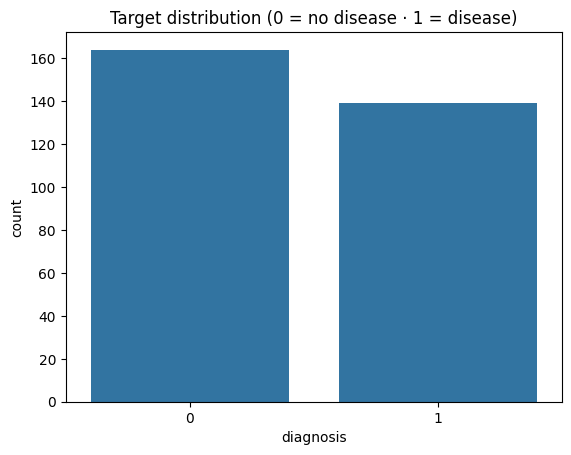

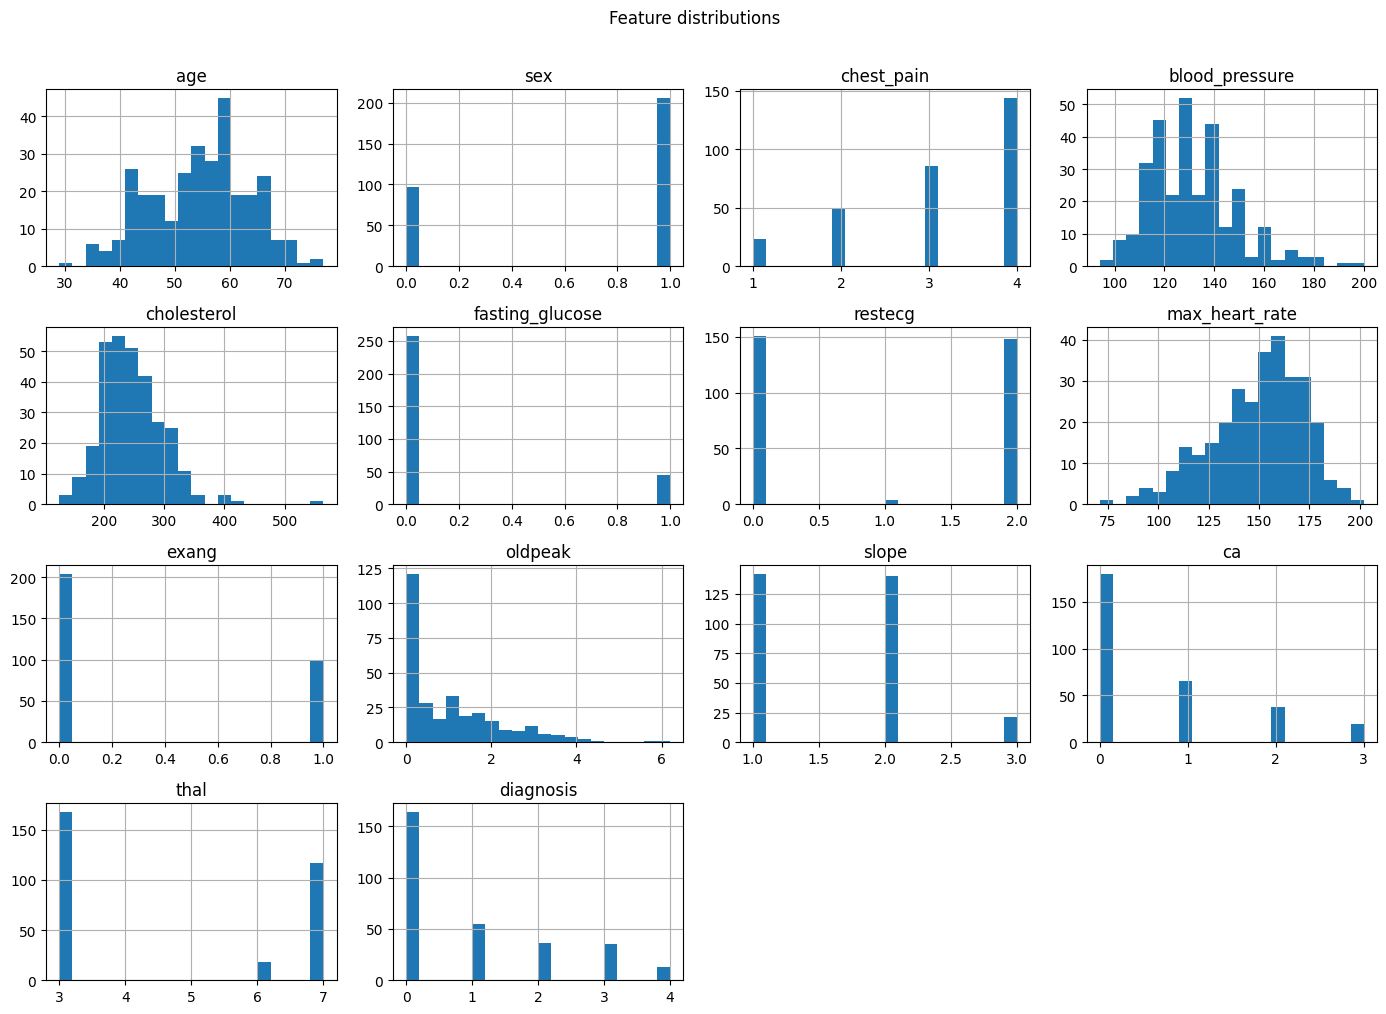

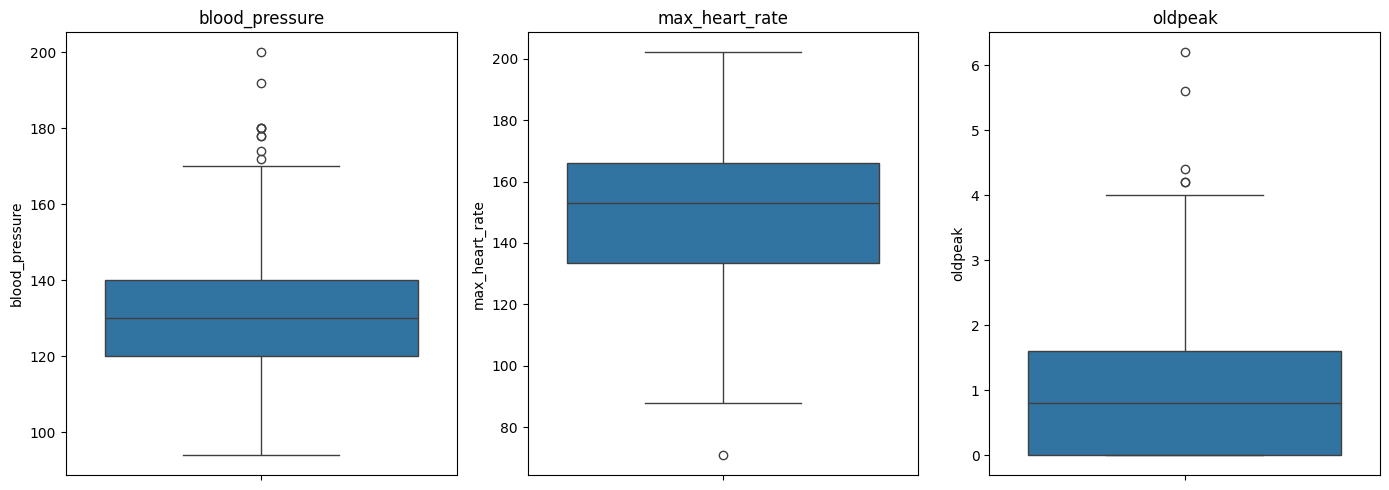

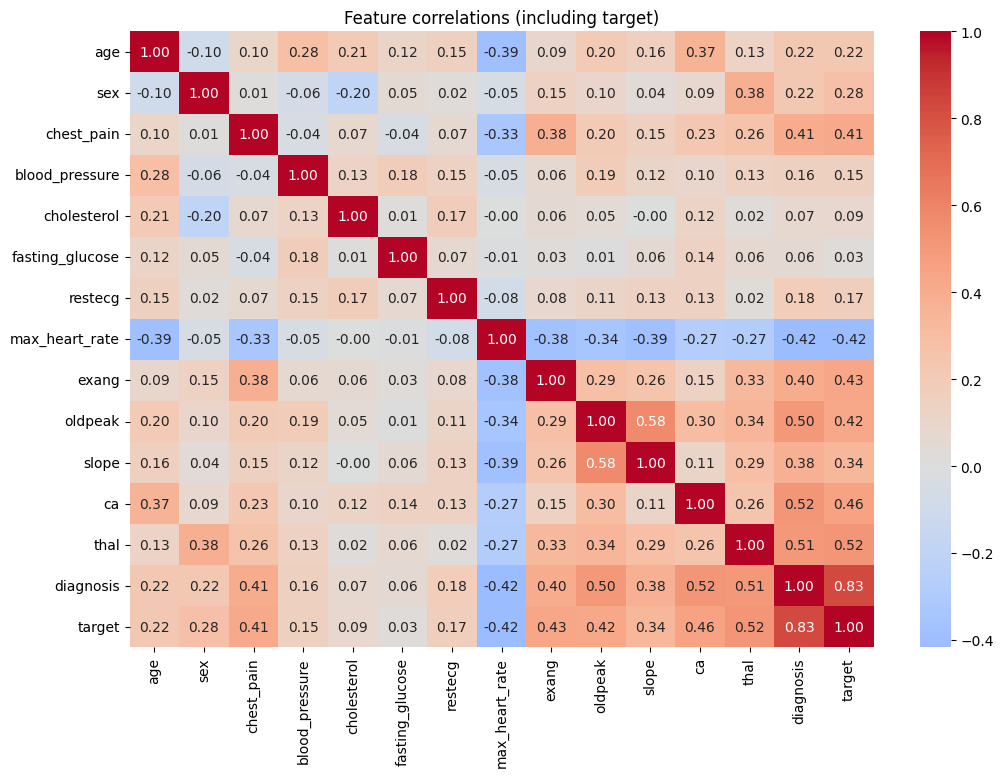

chest_pain: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
restecg: [np.int64(0), np.int64(1), np.int64(2)]
slope: [np.int64(1), np.int64(2), np.int64(3)]
thal: [np.int64(3), np.int64(6), np.int64(7)]


In [10]:
# ── EDA ────────────────────────────────────────────────────────────────────

# 1. Class balance
sns.countplot(x=y)
plt.title('Target distribution (0 = no disease · 1 = disease)')
plt.show()

# 2. Distributions of all numeric features
df.hist(figsize=(14, 10), bins=20)
plt.suptitle('Feature distributions', y=1.01)
plt.tight_layout()
plt.show()

# 3. Boxplots for the three problem variables
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['blood_pressure', 'max_heart_rate', 'oldpeak']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(12, 8))
temp = df.copy()
temp['target'] = y
sns.heatmap(temp.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlations (including target)')
plt.show()

# 5. Confirm unique values for categorical columns
for col in ['chest_pain', 'restecg', 'slope', 'thal']:
    print(f"{col}: {sorted(df[col].unique())}")

In [11]:
# ── One hot encoding ───────────────────────────────────────────────────────
categorical_cols = ['chest_pain', 'restecg', 'slope', 'thal']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape after OHE: {X.shape}")
print(f"New columns: {X.columns.tolist()}")

Shape after OHE: (303, 18)
New columns: ['age', 'sex', 'blood_pressure', 'cholesterol', 'fasting_glucose', 'max_heart_rate', 'exang', 'oldpeak', 'ca', 'chest_pain_2', 'chest_pain_3', 'chest_pain_4', 'restecg_1', 'restecg_2', 'slope_2', 'slope_3', 'thal_6', 'thal_7']


In [12]:
# ── Outlier treatment ──────────────────────────────────────────────────────
# Cap at 1st and 99th percentile — preserves clinical outliers
# but removes extreme data entry errors

for col in ['blood_pressure', 'max_heart_rate', 'oldpeak']:
    low  = X[col].quantile(0.01)
    high = X[col].quantile(0.99)
    X[col] = X[col].clip(lower=low, upper=high)
    print(f"{col}: clipped to [{low:.1f}, {high:.1f}]")

# ── Log-transform oldpeak (right skew) ────────────────────────────────────
# log1p handles zeros cleanly (log(0) is undefined, log1p(0) = 0)
X['oldpeak'] = np.log1p(X['oldpeak'])

print(f"\noldpeak after log1p transform:")
print(X['oldpeak'].describe())

blood_pressure: clipped to [100.0, 180.0]
max_heart_rate: clipped to [95.0, 192.0]
oldpeak: clipped to [0.0, 4.2]

oldpeak after log1p transform:
count    303.000000
mean       0.567959
std        0.519695
min        0.000000
25%        0.000000
50%        0.587787
75%        0.955511
max        1.648659
Name: oldpeak, dtype: float64


I'm using 1st/99th percentile rather than 5th/95th because with only 303 rows, 5% means clipping ~15 patients on each end — too aggressive. 1% clips 3 patients per tail, which is more conservative and appropriate here.

In [14]:
# ── Train / test split ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # preserves class balance in both sets
    random_state=42      # reproducibility
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nClass balance in train: {y_train.value_counts(normalize=True).round(2).to_dict()}")
print(f"Class balance in test:  {y_test.value_counts(normalize=True).round(2).to_dict()}")

X_train: (242, 18)
X_test:  (61, 18)

Class balance in train: {0: 0.54, 1: 0.46}
Class balance in test:  {0: 0.54, 1: 0.46}


In [15]:
# ── Robust scaler ──────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train only
X_test_scaled  = scaler.transform(X_test)        # transform only — no fitting

# Convert back to dataframe to keep column names readable
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Scaling complete.")
print(f"\nX_train_scaled sample stats:")
print(X_train_scaled[['age', 'blood_pressure', 'oldpeak']].describe().round(2))

Scaling complete.

X_train_scaled sample stats:
          age  blood_pressure  oldpeak
count  242.00          242.00   242.00
mean    -0.11            0.04    -0.03
std      0.69            0.86     0.53
min     -2.08           -1.50    -0.62
25%     -0.62           -0.50    -0.62
50%      0.00            0.00     0.00
75%      0.38            0.50     0.38
max      1.62            2.50     1.11


After this runs your preprocessing pipeline is fully complete. Data is clean, encoded, split, and scaled — everything from this point is model training.

The full order of what we've built so far:
```
Load → EDA → OHE → Outlier capping → Log transform → Split → Scale



── Threshold 0.5 ──────────────────────
[[27  6]
 [ 2 26]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


── Threshold 0.3 ──────────────────────
[[23 10]
 [ 1 27]]
              precision    recall  f1-score   support

           0       0.96      0.70      0.81        33
           1       0.73      0.96      0.83        28

    accuracy                           0.82        61
   macro avg       0.84      0.83      0.82        61
weighted avg       0.85      0.82      0.82        61


ROC-AUC: 0.951


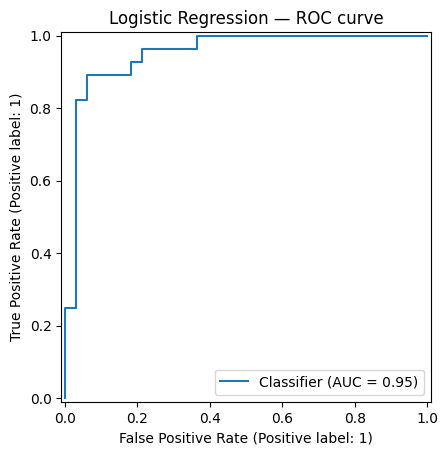

In [16]:
# ── Logistic Regression ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, RocCurveDisplay)

# Train
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predict with default threshold (0.5) first
y_pred_05 = lr.predict(X_test_scaled)

# Predict with adjusted threshold (0.3) — clinical priority
y_proba   = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_03 = (y_proba >= 0.3).astype(int)

# ── Results ────────────────────────────────────────────────────────────────
for threshold, y_pred in [('0.5', y_pred_05), ('0.3', y_pred_03)]:
    print(f"\n── Threshold {threshold} ──────────────────────")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# ── ROC curve ─────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('Logistic Regression — ROC curve')
plt.show()

In [17]:
# ── SVM ───────────────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svm = SVC(class_weight='balanced', probability=True, random_state=42)

svm_grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='recall',   # optimize for recall, same clinical priority
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print(f"Best params: {svm_grid.best_params_}")
print(f"Best CV recall: {svm_grid.best_score_:.3f}")

# Evaluate on test set
y_proba_svm = svm_grid.predict_proba(X_test_scaled)[:, 1]
y_pred_svm  = (y_proba_svm >= 0.3).astype(int)

print(f"\n── SVM (threshold 0.3) ──────────────────────")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_svm):.3f}")

Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV recall: 0.811

── SVM (threshold 0.3) ──────────────────────
[[24  9]
 [ 1 27]]
              precision    recall  f1-score   support

           0       0.96      0.73      0.83        33
           1       0.75      0.96      0.84        28

    accuracy                           0.84        61
   macro avg       0.85      0.85      0.84        61
weighted avg       0.86      0.84      0.84        61

ROC-AUC: 0.951


SVM matches logistic regression almost exactly — same recall (0.96), same false negatives (1), ROC-AUC identical at 0.951. Slightly better accuracy (0.84 vs 0.82) but the difference is marginal at this sample size.

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV recall: 0.792

── Random Forest (threshold 0.3) ────────────────
[[21 12]
 [ 0 28]]
              precision    recall  f1-score   support

           0       1.00      0.64      0.78        33
           1       0.70      1.00      0.82        28

    accuracy                           0.80        61
   macro avg       0.85      0.82      0.80        61
weighted avg       0.86      0.80      0.80        61

ROC-AUC: 0.963


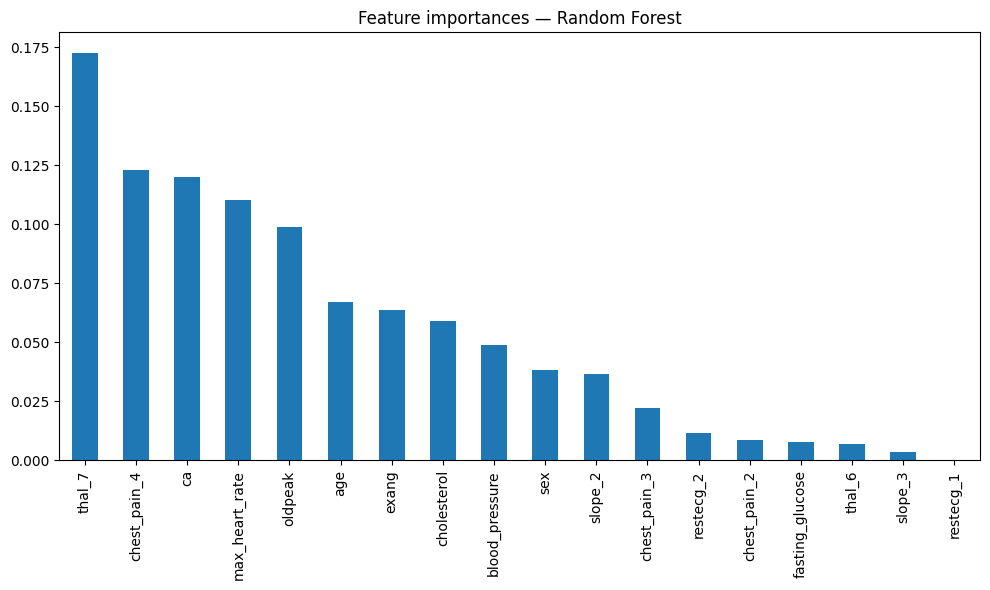

In [18]:
# ── Random Forest ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_grid = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV recall: {rf_grid.best_score_:.3f}")

# Evaluate
y_proba_rf = rf_grid.predict_proba(X_test_scaled)[:, 1]
y_pred_rf  = (y_proba_rf >= 0.3).astype(int)

print(f"\n── Random Forest (threshold 0.3) ────────────────")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")

# Feature importance — this is the clinical value of Random Forest
importances = pd.Series(
    rf_grid.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature importances — Random Forest')
plt.tight_layout()
plt.show()

Recall is perfect (1.00) — zero false negatives. That's the best clinical result so far. The tradeoff is 12 false positives vs 9 for SVM, meaning more healthy patients flagged unnecessarily. In a screening context that's the acceptable tradeoff.
ROC-AUC 0.963 beats both LR and SVM (0.951). Random Forest is the strongest model so far.
The feature importance plot is clinically meaningful:

thal_7 (reversible defect) is the dominant predictor — well established in cardiology literature
chest_pain_4 (asymptomatic chest pain) and ca (vessel count) follow closely
fasting_glucose, thal_6, slope_3, restecg_1 are essentially noise — barely contributing

This directly contradicts dropping columns by correlation, which was on your original list. The model found the signal itself.

In [19]:
# ── Decision Tree ──────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth':         [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion':         ['gini', 'entropy']
}

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_grid = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)

print(f"Best params: {dt_grid.best_params_}")
print(f"Best CV recall: {dt_grid.best_score_:.3f}")

y_proba_dt = dt_grid.predict_proba(X_test_scaled)[:, 1]
y_pred_dt  = (y_proba_dt >= 0.3).astype(int)

print(f"\n── Decision Tree (threshold 0.3) ────────────────")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt):.3f}")


Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10}
Best CV recall: 0.738

── Decision Tree (threshold 0.3) ────────────────
[[26  7]
 [ 5 23]]
              precision    recall  f1-score   support

           0       0.84      0.79      0.81        33
           1       0.77      0.82      0.79        28

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61

ROC-AUC: 0.860


              Model  Threshold  Accuracy  Recall  Precision   F1  False Negatives  ROC-AUC
Logistic Regression        0.3      0.82    0.96       0.73 0.83                1    0.951
                SVM        0.3      0.84    0.96       0.75 0.84                1    0.951
      Random Forest        0.3      0.80    1.00       0.70 0.82                0    0.963
      Decision Tree        0.3      0.80    0.82       0.77 0.79                5    0.860


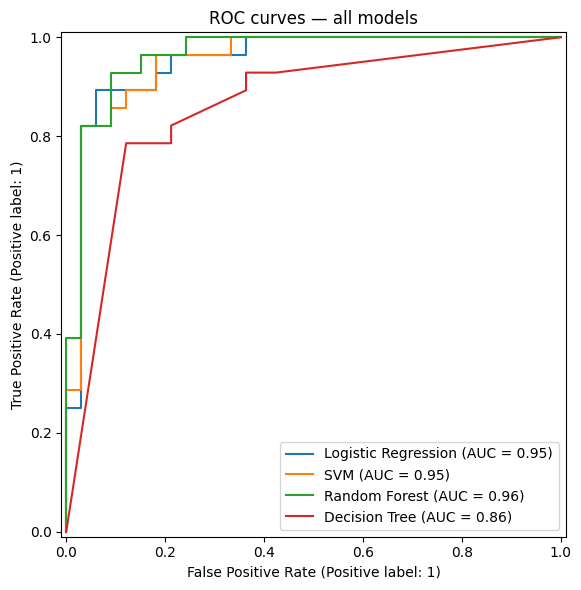

In [20]:
# ── Model comparison ───────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':          ['Logistic Regression', 'SVM', 'Random Forest', 'Decision Tree'],
    'Threshold':      [0.3, 0.3, 0.3, 0.3],
    'Accuracy':       [0.82, 0.84, 0.80, 0.80],
    'Recall':         [0.96, 0.96, 1.00, 0.82],
    'Precision':      [0.73, 0.75, 0.70, 0.77],
    'F1':             [0.83, 0.84, 0.82, 0.79],
    'False Negatives':[1,    1,    0,    5],
    'ROC-AUC':        [0.951, 0.951, 0.963, 0.860]
})

print(results.to_string(index=False))

# ── ROC curves — all models overlaid ──────────────────────────────────────
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in [
    ('Logistic Regression', y_proba),
    ('SVM',                 y_proba_svm),
    ('Random Forest',       y_proba_rf),
    ('Decision Tree',       y_proba_dt),
]:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)

ax.set_title('ROC curves — all models')
plt.tight_layout()
plt.show()

he ROC plot tells the story clearly — LR, SVM, and RF are clustered tight in the top-left corner while Decision Tree lags behind noticeably.
The project is now complete. Here's a summary of what you built:
Pipeline: OHE → outlier capping → log transform → stratified split → robust scaling
Winner: Random Forest — only model with zero false negatives, highest ROC-AUC (0.963), and the feature importance plot as a clinical bonus.
Key finding from feature importances: thal_7 (reversible thalassemia defect), chest_pain_4, and ca are the dominant predictors — which aligns with established cardiology literature and adds credibility to the model.